In [1]:
import sys
sys.path.append("../src")

import diff
import importlib

importlib.reload(diff)

print(dir(diff))

['PCA', 'StandardScaler', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'differential_expression', 'multipletests', 'np', 'pca_plot', 'pd', 'plt', 'ttest_ind', 'volcano_plot']


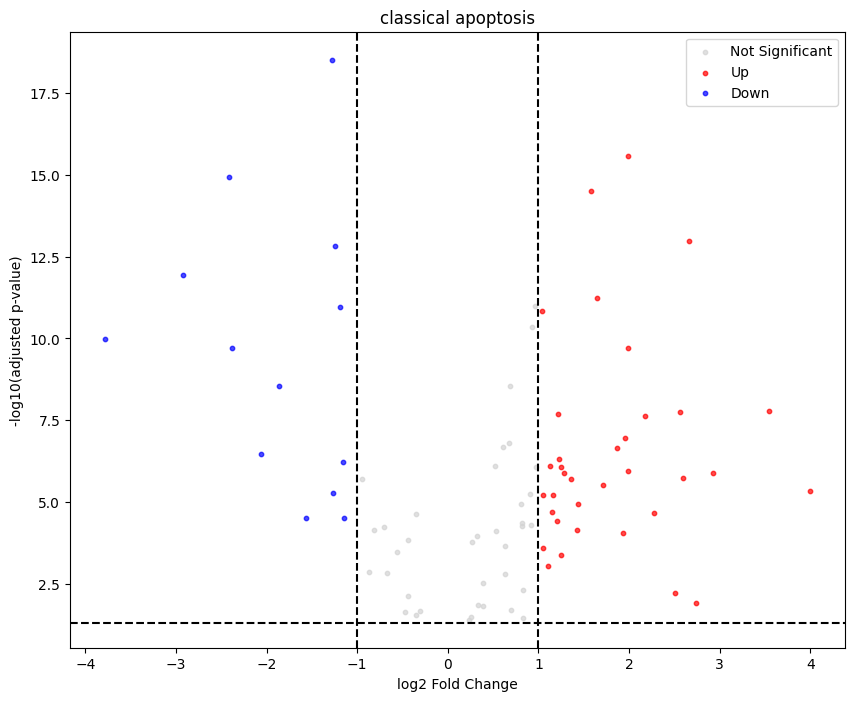

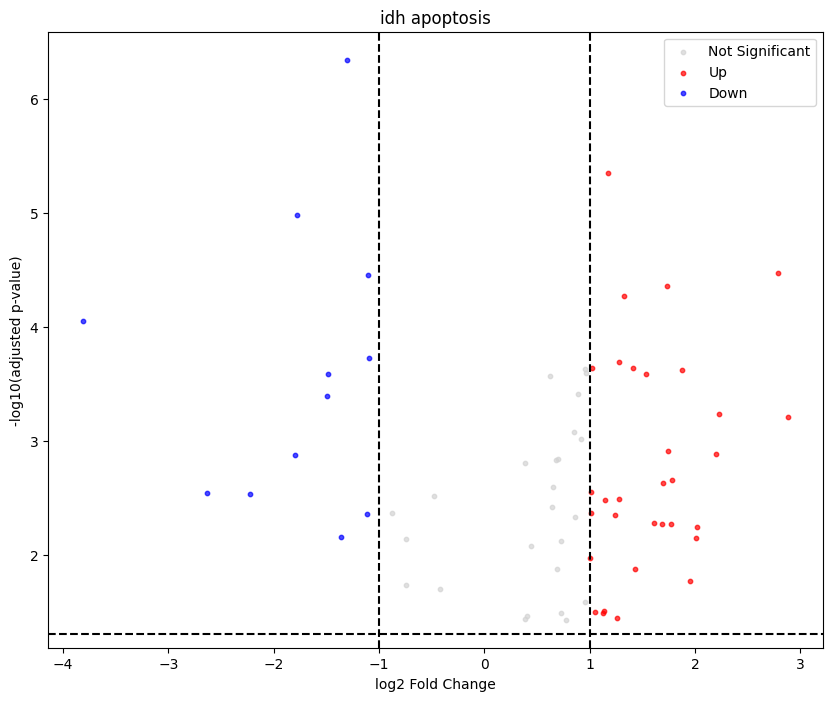

In [2]:
import pandas as pd
clas = pd.read_csv("../data/processed/pathway_diff/classical/classical_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]
idh = pd.read_csv("../data/processed/pathway_diff/idh/idh_Apoptosis_diff.csv",index_col=0)[["log2FC_rna","-log(adjustedp)_rna","category_rna"]]

diff.volcano_plot(clas,'classical apoptosis')
diff.volcano_plot(idh,'idh apoptosis')

In [1]:
import pandas as pd
from pathlib import Path

subtypes = [
    "proneural",
    "classical",
    "mesenchymal",
    "idh"
]

input_dir = Path("../data/interim")
output_dir = Path("../data/processed/diff")

for subtype in subtypes:

    rna = pd.read_csv(
        input_dir / f"{subtype}_rna_diff.csv",
        index_col=0
    )

    prot = pd.read_csv(
        input_dir / f"{subtype}_pro_diff.csv",
        index_col=0
    )

    # Keep only genes present in both datasets
    common = rna.index.intersection(prot.index)

    combined = (
        rna.loc[common]
        .join(
            prot.loc[common],
            lsuffix="_rna",
            rsuffix="_prot"
        )
        .sort_index()
    )

    combined.to_csv(
        output_dir / f"{subtype}_combined.csv"
    )

    print(f"{subtype}: {combined.shape[0]} genes")

proneural: 10074 genes
classical: 10074 genes
mesenchymal: 10074 genes
idh: 10074 genes


c:\Users\haina\AppData\Local\Programs\Python\Python311\Lib\site-packages\matplotlib_venn\_util.py:62: UserWarning: venn3_unweighted is deprecated. Use venn3 with the appropriate layout_algorithm instead.
  warnings.warn(


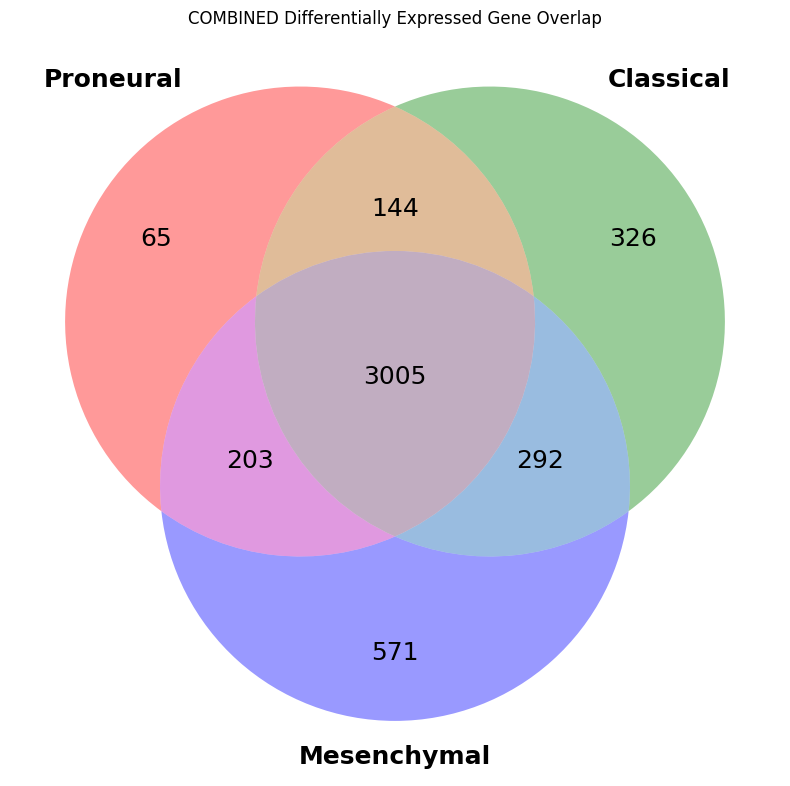

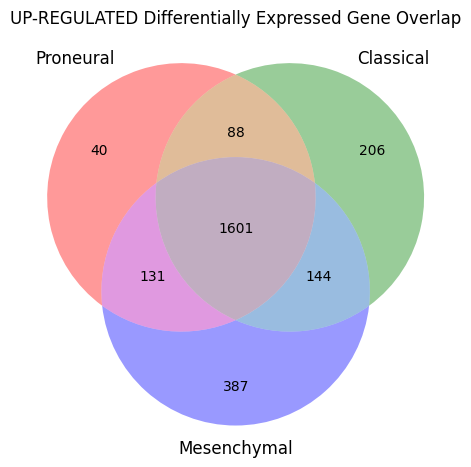

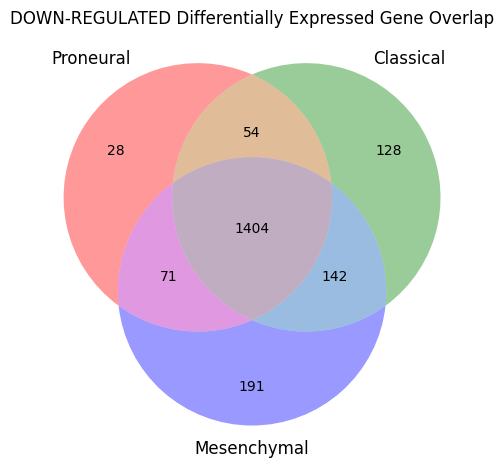

In [6]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn3_unweighted
import pandas as pd

# -----------------------------
# Settings
# -----------------------------
PVAL_COLUMN = "pvalue"
LOGFC_COLUMN = "log2FC"
GENE_COLUMN = "gene_name"

PVAL_THRESHOLD = 0.05
LOGFC_THRESHOLD = 1

files = {
    "Proneural": "../data/interim/proneural_rna_diff.csv",
    "Classical": "../data/interim/classical_rna_diff.csv",
    "Mesenchymal": "../data/interim/mesenchymal_rna_diff.csv"
}

# -----------------------------
# Load DEG sets
# -----------------------------
gene_sets = {}
gene_sets_up = {}
gene_sets_down = {}

for subtype, file in files.items():

    df = pd.read_csv(file)

    sig = df[
        (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
        (abs(df[LOGFC_COLUMN]) > LOGFC_THRESHOLD)
    ]

    sig_up  = df[
    (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
    (df[LOGFC_COLUMN] > LOGFC_THRESHOLD)
    ]
    
    sig_down = df[
    (df[PVAL_COLUMN] < PVAL_THRESHOLD) &
    (df[LOGFC_COLUMN] < -LOGFC_THRESHOLD)
    ]
    
    gene_sets[subtype] = set(
        sig[GENE_COLUMN]
        .dropna()
        .astype(str)
    )

    gene_sets_up[subtype] = set(
        sig_up[GENE_COLUMN]
        .dropna()
        .astype(str)
    )    

    gene_sets_down[subtype] = set(
        sig_down[GENE_COLUMN]
        .dropna()
        .astype(str)
    )    

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(8,8))

v = venn3_unweighted(
    [
        gene_sets["Proneural"],
        gene_sets["Classical"],
        gene_sets["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

# Increase number size
for text in v.subset_labels:
    if text is not None:
        text.set_fontsize(18)   # try 18–24

# Increase subtype label size
for text in v.set_labels:
    if text is not None:
        text.set_fontsize(18)
        text.set_fontweight("bold")


plt.title("COMBINED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()



venn3_unweighted(
    [
        gene_sets_up["Proneural"],
        gene_sets_up["Classical"],
        gene_sets_up["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

plt.title("UP-REGULATED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()

venn3_unweighted(
    [
        gene_sets_down["Proneural"],
        gene_sets_down["Classical"],
        gene_sets_down["Mesenchymal"]
    ],
    set_labels=("Proneural", "Classical", "Mesenchymal")
)

plt.title("DOWN-REGULATED Differentially Expressed Gene Overlap")
plt.tight_layout()
plt.show()